In [ ]:
# repo-root bootstrap: notebooks live in notebooks/, code lives one level up
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root / "spphot_eval.py").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

data = pd.read_parquet('/scratch/mk27/mj8805/spphot_nn_studentt.parquet')

In [15]:
import numpy as np

In [16]:
data.head()

,sdss_id,plx,e_plx,plx_raw,zeropoint,plx_sp,err_sp,dist_sp_kpc,r_med_photogeo_pc,sample,train,spec_bad_frac
0,100000028,0.164583,0.023733,0.120654,-0.043929,0.185308,0.000141,5.396411,5847.649902,B,False,0.101691
1,100000156,0.058013,0.035814,0.015124,-0.042889,0.129652,0.000141,7.712949,10633.925781,B,False,0.107172
2,100000167,0.164350,0.016947,0.122790,-0.041560,0.168372,0.003525,5.939235,5986.399902,B,True,0.097259
3,100000172,0.142142,0.020179,0.101950,-0.040192,0.248696,0.000141,4.020966,7088.578125,A,False,0.100991
4,100000181,0.134440,0.017905,0.083680,-0.050760,0.125541,0.000141,7.965497,7917.260254,B,False,0.097376


In [17]:
data_filt = data[(data['plx'] < 2) & (data['plx'] > 0) & (data['plx_sp'] < 2) & (data['plx_sp'] > 0)]

In [18]:
len(data_filt)

706016

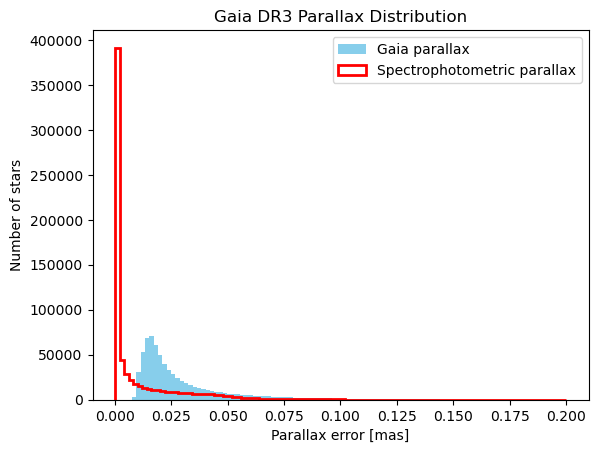

In [24]:
data_filt_hist = data_filt[(data_filt['e_plx'] < 0.2) & (data_filt['err_sp'] < 0.2)]
plt.hist(data_filt_hist['e_plx'], bins=100, color='skyblue', label='Gaia parallax');
plt.hist(data_filt_hist['err_sp'], bins=100, color='red', label='Spectrophotometric parallax', histtype='step', linewidth=2);
plt.xlabel('Parallax error [mas]');
plt.ylabel('Number of stars');
plt.title('Gaia DR3 Parallax Distribution');
plt.legend();
plt.show();

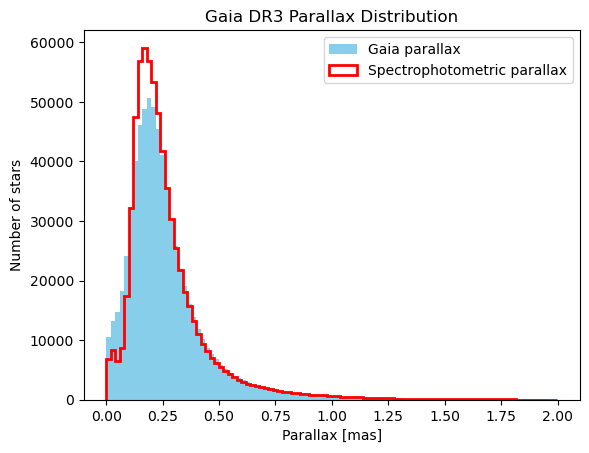

In [20]:
plt.hist(data_filt['plx'], bins=100, color='skyblue', label='Gaia parallax');
plt.hist(data_filt['plx_sp'], bins=100, color='red', label='Spectrophotometric parallax', histtype='step', linewidth=2);
plt.xlabel('Parallax [mas]');
plt.ylabel('Number of stars');
plt.title('Gaia DR3 Parallax Distribution');
plt.legend();
plt.show();


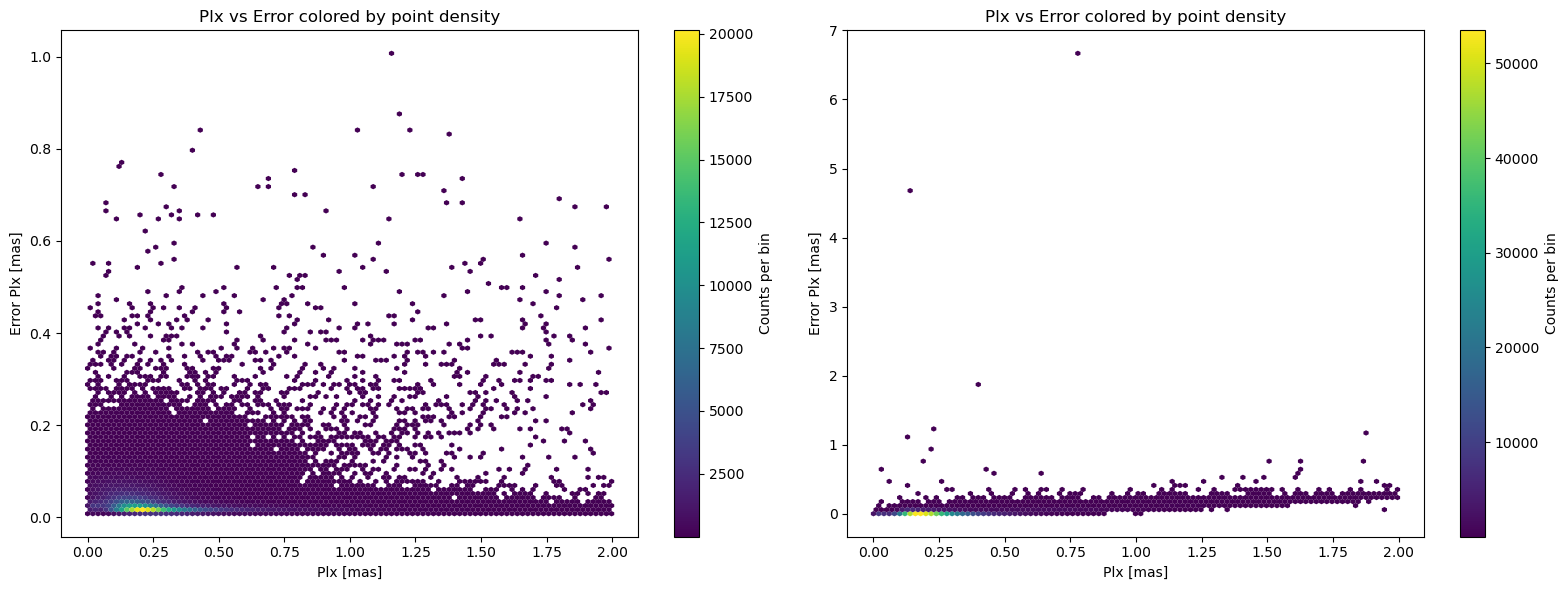

In [21]:
# Use a 2d histogram (hexbin) for much faster density plotting

fig, ax = plt.subplots(ncols=2, figsize=(16,6))

x = data_filt['plx'].values
y = data_filt['e_plx'].values
x2 = data_filt['plx_sp'].values
y2 = data_filt['err_sp'].values

hb = ax[0].hexbin(x, y, gridsize=100, cmap='viridis', mincnt=1, linewidths=0)
ax[0].set_xlabel('Plx [mas]')
ax[0].set_ylabel('Error Plx [mas]')
ax[0].set_title('Plx vs Error colored by point density')
fig.colorbar(hb, ax=ax[0], label='Counts per bin')

hb2 = ax[1].hexbin(x2, y2, gridsize=100, cmap='viridis', mincnt=1, linewidths=0)
ax[1].set_xlabel('Plx [mas]')
ax[1].set_ylabel('Error Plx [mas]')
ax[1].set_title('Plx vs Error colored by point density')
fig.colorbar(hb2, ax=ax[1], label='Counts per bin')

fig.tight_layout()
plt.show()

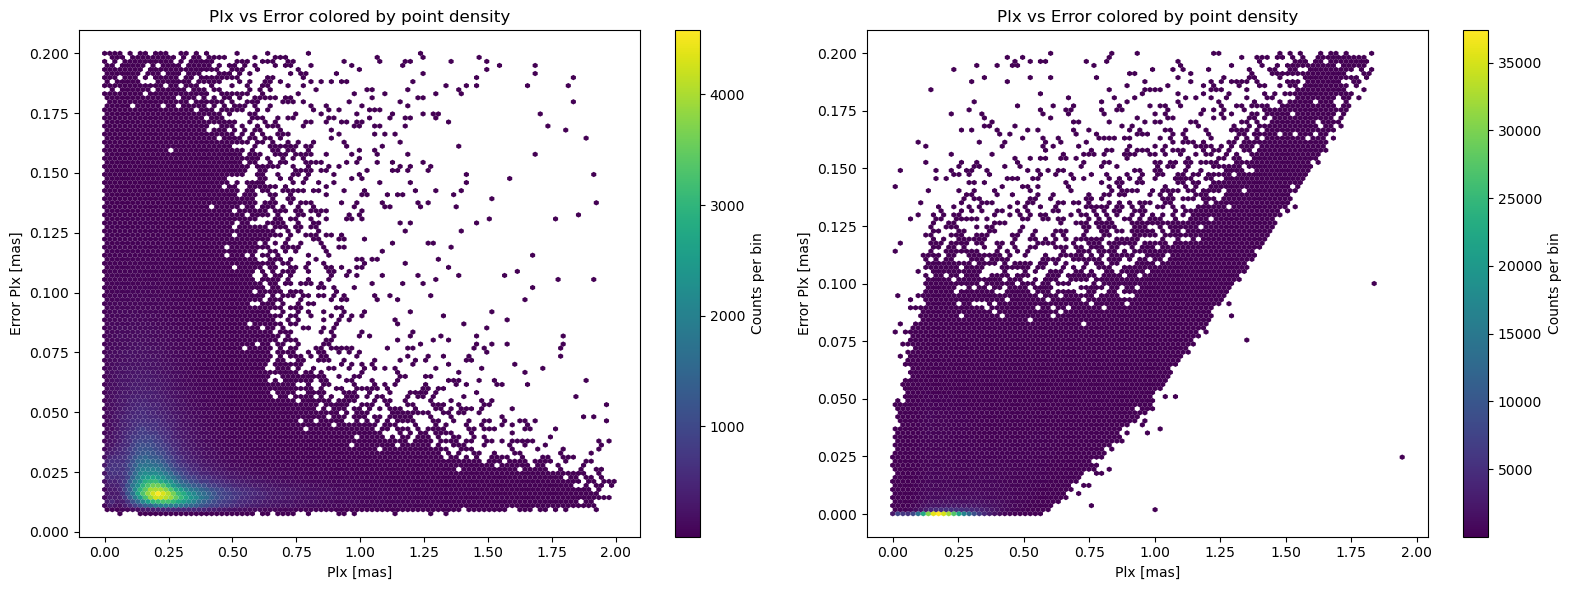

In [25]:
fig, ax = plt.subplots(ncols=2, figsize=(16,6))

data_filt_hexbin = data_filt[(data_filt['e_plx'] < 0.2) & (data_filt['err_sp'] < 0.2)]

x = data_filt_hexbin['plx'].values
y = data_filt_hexbin['e_plx'].values
x2 = data_filt_hexbin['plx_sp'].values
y2 = data_filt_hexbin['err_sp'].values

hb = ax[0].hexbin(x, y, gridsize=100, cmap='viridis', mincnt=1, linewidths=0)
ax[0].set_xlabel('Plx [mas]')
ax[0].set_ylabel('Error Plx [mas]')
ax[0].set_title('Plx vs Error colored by point density')
fig.colorbar(hb, ax=ax[0], label='Counts per bin')

hb2 = ax[1].hexbin(x2, y2, gridsize=100, cmap='viridis', mincnt=1, linewidths=0)
ax[1].set_xlabel('Plx [mas]')
ax[1].set_ylabel('Error Plx [mas]')
ax[1].set_title('Plx vs Error colored by point density')
fig.colorbar(hb2, ax=ax[1], label='Counts per bin')

fig.tight_layout()
plt.show()

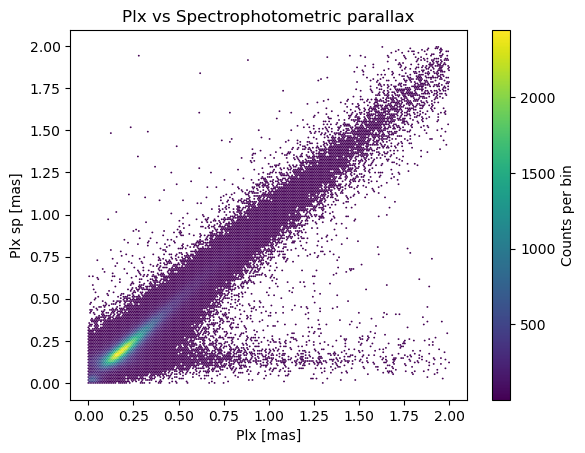

In [22]:
x = data_filt['plx'].values
y = data_filt['plx_sp'].values

hb = plt.hexbin(x, y, gridsize=200, cmap='viridis', mincnt=1, linewidths=0)
plt.xlabel('Plx [mas]')
plt.ylabel('Plx sp [mas]')
plt.title('Plx vs Spectrophotometric parallax')
plt.colorbar(label='Counts per bin')

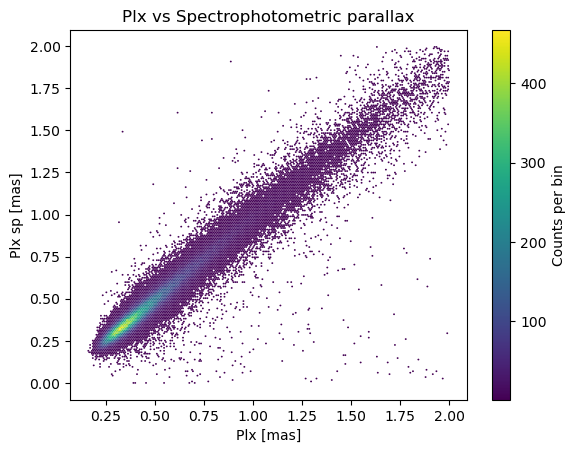

In [23]:
data_good = data_filt[(data_filt['plx']/data_filt['e_plx']) > 20.0]
x = data_good['plx'].values
y = data_good['plx_sp'].values

hb = plt.hexbin(x, y, gridsize=200, cmap='viridis', mincnt=1, linewidths=0)
plt.xlabel('Plx [mas]')
plt.ylabel('Plx sp [mas]')
plt.title('Plx vs Spectrophotometric parallax')
plt.colorbar(label='Counts per bin')

In [ ]:
import sys
sys.path.append('/home/100/mj8805/scr_mk27/distance-estimator')

import pandas as pd, spphot_eval as E
df = data[data["train"]]                       # score on the cross-validated training set
cat = {"plx_a": df["plx"].to_numpy(), "err_a": df["e_plx"].to_numpy(),
        "plx_sp": df["plx_sp"].to_numpy(), "err_sp": df["err_sp"].to_numpy(),
        "sample": df["sample"].to_numpy()}
E.print_report(E.evaluate(cat, label="het-NN"))
E.print_calibration(*E.calibrate(cat))
for f in ("A", "B"):
    E.print_calibration(*E.calibrate(cat, fold=f))

=== het-NN  (fold: all) ===
  N total / hi-S/N probe : 216175 / 73205
  bias  (median frac resid)  : -1.19 %
  SCATTER (robust frac, <9% = beats Paper I) : 8.26 %
  median quoted spec err frac: 3.56 %
  chi2  mean / median / robust : 4.33 / 1.02 / 2.23
    (mean chi2 >> 1 means outlier-driven; honest errors -> ~1)
  error calibration (high-S/N probe, binned by predicted err frac):
    pred%   obs%   obs/pred  robustChi    N
     0.61   9.04    14.80      2.40     9151
     1.60   8.39     5.24      2.29     9150
     2.73   8.14     2.98      1.99     9151
     3.94   7.50     1.91      1.60     9150
     5.10   7.12     1.39      1.30     9151
     6.28   6.42     1.02      1.05     9150
     7.54   6.65     0.88      0.92     9151
    10.18   8.12     0.80      0.81     9151
    (obs/pred & robustChi > 1 -> overconfident; flat across rows = scalar recal ok, trend = needs mag-dependent recal)
  global recal factor (err_sp *= c -> robust chi ~ 1): c = 2.482
  error calibration (high-S/